# Notebook 06 — Fermi-Surface Evolution and Metal–Insulator Transition

Full 2D diagonalization on a uniform $200 \times 200$ grid covering BZ1, for four values of $V_0$. For each, locate $E_F$ from divalent filling ($n_{\text{cell}} = 2$, $g_s = 2$ ⇒ fill the lowest $N_k$ band-states) and contour the first two bands at $E = E_F$.

At $V_0 = 0$ the bands strongly overlap (overlap $= \min E_2 - \max E_1 = -\pi^2 \approx -9.87$). As $V_0$ grows the X-gap pushes $E_2$ up by $\sim V_0/2$ and the M-degeneracy splits $E_1$ downward, so the overlap shrinks and eventually reverses sign — at that $V_0$ the system becomes an insulator and the Fermi surfaces vanish.

In [1]:
import sys
import time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from src.hamiltonian import cosine_potential
from src.fermi import (
    compute_bands_on_grid,
    find_E_F,
    band_overlap,
    wrap_for_plot,
)

FIG_DIR = ROOT / "figures" / "06_metal_insulator"
FIG_DIR.mkdir(parents=True, exist_ok=True)

N_KX = N_KY = 200
N_CUT = 3
V_0_PANELS = [0.0, 0.5, 2.0, 7.0]

In [ ]:
results = {}
print(f"Grid: {N_KX} x {N_KY} = {N_KX * N_KY} k-points; basis size N_pw = {(2*N_CUT+1)**2}")
print(f"H_batch memory: {(N_KX*N_KY) * ((2*N_CUT+1)**2)**2 * 16 / 1e9:.2f} GB (complex128)")
print()

for V_0 in V_0_PANELS:
    V_func = cosine_potential(V_0)
    t0 = time.time()
    KX, KY, E_grid = compute_bands_on_grid(N_KX, N_KY, V_func, N_CUT)
    t1 = time.time()
    E_F = find_E_F(E_grid, n_per_cell=2, g_s=2)
    overlap = band_overlap(E_grid, bands=(0, 1))
    results[V_0] = {"KX": KX, "KY": KY, "E_grid": E_grid, "E_F": E_F, "overlap": overlap}
    print(f"V_0={V_0:>4.1f}  diag={t1-t0:.2f}s  E_F={E_F:>7.4f}  "
          f"min(E_2)={np.min(E_grid[..., 1]):>7.4f}  max(E_1)={np.max(E_grid[..., 0]):>7.4f}  "
          f"overlap={overlap:+.4f}")

print(f"\nSanity: at V_0=0, E_F should equal k_F^2 = 4*pi = {4*np.pi:.4f}")
print(f"        Empty-lattice band overlap = -pi^2 = {-np.pi**2:.4f}")

Grid: 200 x 200 = 40000 k-points; basis size N_pw = 49
H_batch memory: 1.54 GB (complex128)

V_0= 0.0  diag=1.47s  E_F=12.5739  min(E_2)= 9.8696  max(E_1)=19.7392  overlap=-9.8696
V_0= 0.5  diag=5.38s  E_F=12.5671  min(E_2)=10.1156  max(E_1)=19.2376  overlap=-9.1220
V_0= 2.0  diag=5.63s  E_F=12.5567  min(E_2)=10.8062  max(E_1)=17.7142  overlap=-6.9080


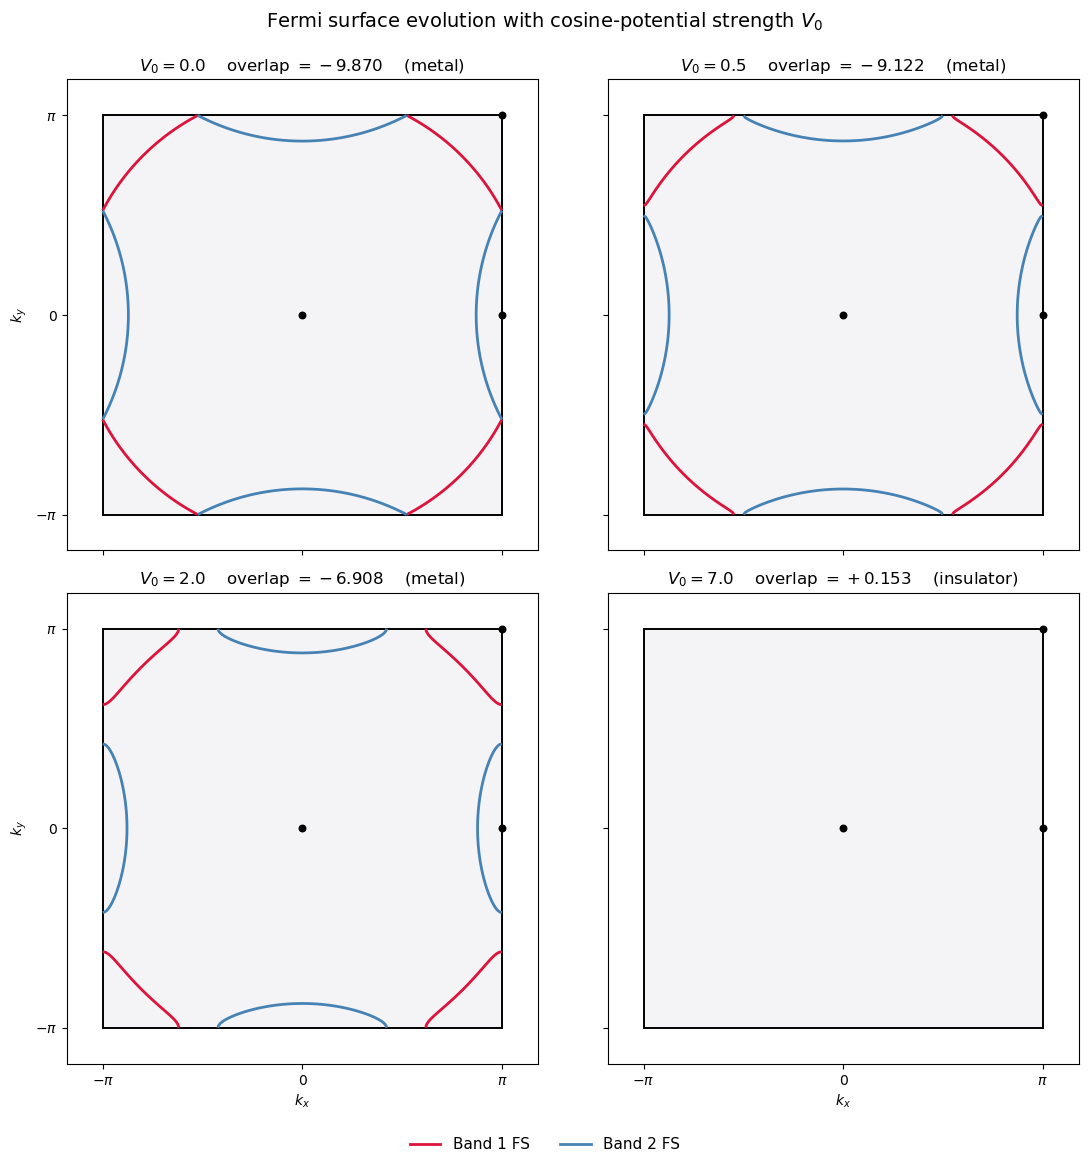

In [ ]:
BAND1_COLOR = "crimson"
BAND2_COLOR = "steelblue"
BZ_FILL = "#f4f4f6"

fig, axes = plt.subplots(2, 2, figsize=(11.5, 11.5), sharex=True, sharey=True)

for ax, V_0 in zip(axes.ravel(), V_0_PANELS):
    res = results[V_0]
    KX, KY, E_grid, E_F, overlap = (
        res["KX"], res["KY"], res["E_grid"], res["E_F"], res["overlap"]
    )
    KX_p, KY_p, E_plot = wrap_for_plot(KX, KY, E_grid)

    pi = np.pi
    ax.add_patch(Rectangle((-pi, -pi), 2 * pi, 2 * pi,
                           facecolor=BZ_FILL, edgecolor="black",
                           linewidth=1.4, zorder=1))

    # Band 1 Fermi surface (red).
    ax.contour(KX_p, KY_p, E_plot[..., 0], levels=[E_F],
               colors=[BAND1_COLOR], linewidths=2.0, zorder=3)
    # Band 2 Fermi surface (blue). Skip if the band never reaches E_F (insulator).
    if np.min(E_grid[..., 1]) < E_F < np.max(E_grid[..., 1]):
        ax.contour(KX_p, KY_p, E_plot[..., 1], levels=[E_F],
                   colors=[BAND2_COLOR], linewidths=2.0, zorder=3)

    # High-symmetry markers.
    for k, name in [((0, 0), r"$\Gamma$"), ((pi, 0), "X"), ((pi, pi), "M")]:
        ax.scatter(*k, color="black", s=22, zorder=5)

    LIM = 1.18 * pi
    ax.set_xlim(-LIM, LIM)
    ax.set_ylim(-LIM, LIM)
    ax.set_aspect("equal")
    ax.set_xticks([-pi, 0, pi]); ax.set_xticklabels([r"$-\pi$", "0", r"$\pi$"])
    ax.set_yticks([-pi, 0, pi]); ax.set_yticklabels([r"$-\pi$", "0", r"$\pi$"])

    state = "insulator" if overlap > 0 else "metal"
    ax.set_title(rf"$V_0 = {V_0:.1f}$    overlap $= {overlap:+.3f}$    ({state})", fontsize=12)

for ax in axes[-1, :]:
    ax.set_xlabel(r"$k_x$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$k_y$")

band1_proxy = plt.Line2D([0], [0], color=BAND1_COLOR, linewidth=2.0, label="Band 1 FS")
band2_proxy = plt.Line2D([0], [0], color=BAND2_COLOR, linewidth=2.0, label="Band 2 FS")
fig.legend(handles=[band1_proxy, band2_proxy], loc="lower center",
           ncol=2, fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.01))

fig.suptitle("Fermi surface evolution with cosine-potential strength $V_0$",
             fontsize=14, y=0.995)
fig.tight_layout(rect=[0, 0.025, 1, 1])
fig.savefig(FIG_DIR / "figure_06a_fermi_surface_evolution.png", dpi=180, bbox_inches="tight")
plt.show()

## Figure 6b — band overlap and DOS$(E_F)$ vs $V_0$

Sweep $V_0$ from 0 to 8 with 30 samples. For each, run the full diagonalization and record:

- **Band overlap** = $\min E_2(\mathbf{k}) - \max E_1(\mathbf{k})$. Negative ⇒ metal, zero ⇒ transition, positive ⇒ insulator.
- **DOS at $\mu$** = Gaussian-broadened density of states evaluated at the $T=0$ chemical potential, normalized per primitive cell. The chemical potential is the midpoint of the highest filled and lowest unfilled single-particle states; in an insulator this is the gap midpoint, where the DOS truly vanishes (modulo broadening $\sigma$).

The critical $V_0$ where overlap crosses zero should coincide with the $V_0$ at which DOS drops sharply.

In [ ]:
from src.fermi import chemical_potential, dos_at

V_0_SWEEP = np.linspace(0.0, 8.0, 30)
SIGMA_DOS = 0.05

overlaps = np.empty_like(V_0_SWEEP)
dos_at_mu = np.empty_like(V_0_SWEEP)
mu_values = np.empty_like(V_0_SWEEP)

t_start = time.time()
for i, V_0 in enumerate(V_0_SWEEP):
    V_func = cosine_potential(V_0)
    _, _, E_grid = compute_bands_on_grid(N_KX, N_KY, V_func, N_CUT)
    overlaps[i] = band_overlap(E_grid, bands=(0, 1))
    mu_values[i] = chemical_potential(E_grid, n_per_cell=2, g_s=2)
    dos_at_mu[i] = dos_at(mu_values[i], E_grid, sigma=SIGMA_DOS)
    if (i + 1) % 5 == 0 or i == 0:
        elapsed = time.time() - t_start
        print(f"  [{i+1:>2}/{len(V_0_SWEEP)}] V_0={V_0:.3f}  "
              f"overlap={overlaps[i]:+.3f}  mu={mu_values[i]:.3f}  "
              f"DOS={dos_at_mu[i]:.4f}   ({elapsed:.1f}s elapsed)")

# Estimate critical V_0 by linear interpolation at overlap = 0.
sign_change = np.where(np.diff(np.sign(overlaps)) != 0)[0]
if sign_change.size:
    i0 = sign_change[0]
    V0a, V0b = V_0_SWEEP[i0], V_0_SWEEP[i0 + 1]
    Oa, Ob = overlaps[i0], overlaps[i0 + 1]
    V0_critical = V0a - Oa * (V0b - V0a) / (Ob - Oa)
    print(f"\nMetal-insulator transition: V_0_c ≈ {V0_critical:.3f}  "
          f"(linear-interp between V_0={V0a:.3f} and V_0={V0b:.3f})")
else:
    V0_critical = None
    print("\nNo sign change in overlap over the swept range.")

  [ 1/30] V_0=0.000  overlap=-9.870  mu=12.574  DOS=0.0783   (1.5s elapsed)


  [ 5/30] V_0=1.103  overlap=-8.226  mu=12.567  DOS=0.0775   (24.4s elapsed)


  [10/30] V_0=2.483  overlap=-6.205  mu=12.572  DOS=0.0805   (53.0s elapsed)


  [15/30] V_0=3.862  overlap=-4.221  mu=12.565  DOS=0.0792   (82.0s elapsed)


  [20/30] V_0=5.241  overlap=-2.274  mu=12.566  DOS=0.0802   (110.5s elapsed)


  [25/30] V_0=6.621  overlap=-0.366  mu=12.560  DOS=0.0752   (139.4s elapsed)


  [30/30] V_0=8.000  overlap=+1.506  mu=12.107  DOS=0.0000   (168.6s elapsed)

Metal-insulator transition: V_0_c ≈ 6.888  (linear-interp between V_0=6.621 and V_0=6.897)


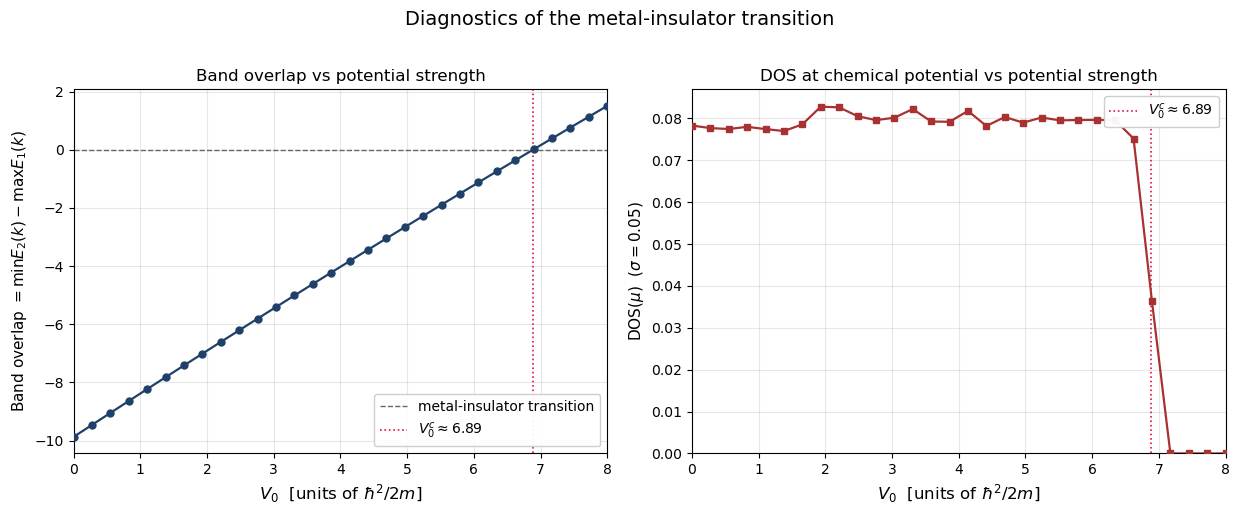

In [ ]:
fig, (ax_overlap, ax_dos) = plt.subplots(1, 2, figsize=(12.5, 5.0))

# Left: band overlap vs V_0
ax_overlap.plot(V_0_SWEEP, overlaps, "o-", color="#1f4068", linewidth=1.6,
                markersize=5, zorder=3)
ax_overlap.axhline(0.0, color="0.4", linestyle="--", linewidth=1.0, zorder=2,
                   label="metal-insulator transition")
if V0_critical is not None:
    ax_overlap.axvline(V0_critical, color="crimson", linestyle=":",
                       linewidth=1.2, zorder=2, label=rf"$V_0^c \approx {V0_critical:.2f}$")
ax_overlap.set_xlabel(r"$V_0$  [units of $\hbar^2/2m$]", fontsize=12)
ax_overlap.set_ylabel(r"Band overlap $= \min E_2(k) - \max E_1(k)$", fontsize=11)
ax_overlap.set_title("Band overlap vs potential strength", fontsize=12)
ax_overlap.set_xlim(V_0_SWEEP[0], V_0_SWEEP[-1])
ax_overlap.grid(True, alpha=0.3)
ax_overlap.legend(loc="lower right", fontsize=10, framealpha=0.95)

# Right: DOS(mu) vs V_0
ax_dos.plot(V_0_SWEEP, dos_at_mu, "s-", color="#a83232", linewidth=1.6,
            markersize=5, zorder=3)
if V0_critical is not None:
    ax_dos.axvline(V0_critical, color="crimson", linestyle=":",
                   linewidth=1.2, zorder=2, label=rf"$V_0^c \approx {V0_critical:.2f}$")
    ax_dos.legend(loc="upper right", fontsize=10, framealpha=0.95)
ax_dos.set_xlabel(r"$V_0$  [units of $\hbar^2/2m$]", fontsize=12)
ax_dos.set_ylabel(rf"DOS$(\mu)$  ($\sigma = {SIGMA_DOS}$)", fontsize=11)
ax_dos.set_title("DOS at chemical potential vs potential strength", fontsize=12)
ax_dos.set_xlim(V_0_SWEEP[0], V_0_SWEEP[-1])
ax_dos.set_ylim(bottom=0.0)
ax_dos.grid(True, alpha=0.3)

fig.suptitle("Diagnostics of the metal-insulator transition", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure_06b_diagnostics.png", dpi=180, bbox_inches="tight")
plt.show()